# AMZON DELIVERY TIME PREDICTION

This project focuses on building a Machine Learning solution to predict delivery times for e-commerce orders on Amazon.
Delivery times depend on multiple factors such as traffic conditions, weather, delivery distance, product type, and delivery agent performance.

**🎯Objectives**

->Clean and preprocess raw delivery data.

->Perform Exploratory Data Analysis (EDA) to understand key factors       affecting delivery times.

->Engineer new features (e.g., distance calculation, time-based variables).

->Train and compare multiple regression models (Linear Regression, Random Forest, Gradient Boosting, XGBoost).

->Use MLflow to track model performance and experiments.

->Develop a Streamlit application where users can input order details and get predicted delivery times.

**📊Business Motivation**

->Improve customer satisfaction with accurate delivery time estimates.

->Optimize logistics and allocate delivery resources efficiently.

->Evaluate agent performance and identify areas for improvement.

->Adapt dynamically to traffic and weather conditions for realistic predictions.

In [1]:
# Day 1 - Data Preparation, Cleaning & Feature Engineering with Quick Visualizations

# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from math import radians, cos, sin, asin, sqrt

In [2]:
# 2. Load dataset
df = pd.read_csv("amazon_delivery.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (43739, 16)
        Order_ID  Agent_Age  Agent_Rating  Store_Latitude  Store_Longitude  \
0  ialx566343618         37           4.9       22.745049        75.892471   
1  akqg208421122         34           4.5       12.913041        77.683237   
2  njpu434582536         23           4.4       12.914264        77.678400   
3  rjto796129700         38           4.7       11.003669        76.976494   
4  zguw716275638         32           4.6       12.972793        80.249982   

   Drop_Latitude  Drop_Longitude  Order_Date Order_Time Pickup_Time  \
0      22.765049       75.912471  2022-03-19   11:30:00    11:45:00   
1      13.043041       77.813237  2022-03-25   19:45:00    19:50:00   
2      12.924264       77.688400  2022-03-19   08:30:00    08:45:00   
3      11.053669       77.026494  2022-04-05   18:00:00    18:10:00   
4      13.012793       80.289982  2022-03-26   13:30:00    13:45:00   

      Weather  Traffic      Vehicle            Area  Delivery_Time  \
0       Sunny  

In [3]:
# 3. Inspect data
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  object 
 8   Order_Time       43739 non-null  object 
 9   Pickup_Time      43739 non-null  object 
 10  Weather          43648 non-null  object 
 11  Traffic          43739 non-null  object 
 12  Vehicle          43739 non-null  object 
 13  Area             43739 non-null  object 
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 5.3+ MB
N

In [4]:
# 4. Handle missing values & duplicates
df.drop_duplicates(inplace=True)
df.fillna({
    "Weather": "Clear",
    "Traffic": "Low",
    "Vehicle": "Bike",
    "Agent_Rating": df["Agent_Rating"].mean()
}, inplace=True)

In [5]:
# 5. Encode categorical variables
cat_cols = ["Weather", "Traffic", "Vehicle", "Area", "Category"]
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [6]:
# 6. Feature Engineering

# --- 6.1 Distance Calculation (Haversine Formula) ---
def haversine(lat1, lon1, lat2, lon2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    r = 6371  # Radius of earth in kilometers
    return c * r

df["Distance_km"] = df.apply(lambda row: haversine(
    row["Store_Latitude"], row["Store_Longitude"],
    row["Drop_Latitude"], row["Drop_Longitude"]), axis=1)

# --- 6.2 Time Features ---
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
# New (robust handling) ✅
df["Order_Time"] = pd.to_datetime(df["Order_Time"], errors='coerce').dt.time
df["Pickup_Time"] = pd.to_datetime(df["Pickup_Time"], errors='coerce').dt.time


df["Order_Hour"] = pd.to_datetime(df["Order_Time"], format='%H:%M:%S').dt.hour
df["Order_Weekday"] = df["Order_Date"].dt.dayofweek
df["Is_Weekend"] = df["Order_Weekday"].apply(lambda x: 1 if x>=5 else 0)

C:\Users\himan\AppData\Local\Temp\ipykernel_11480\744068212.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Order_Time"] = pd.to_datetime(df["Order_Time"], errors='coerce').dt.time
C:\Users\himan\AppData\Local\Temp\ipykernel_11480\744068212.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Pickup_Time"] = pd.to_datetime(df["Pickup_Time"], errors='coerce').dt.time


In [7]:
# 7. Save cleaned dataset
df.to_csv("cleaned_amazon_delivery.csv", index=False)
print("✅ Cleaned dataset saved as cleaned_amazon_delivery.csv")

✅ Cleaned dataset saved as cleaned_amazon_delivery.csv


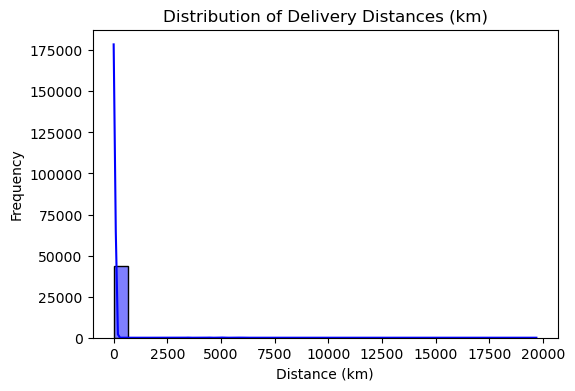

In [9]:
# ---------------------------------------------------------
# 8. Quick Sanity-Check Visualizations
# ---------------------------------------------------------

plt.figure(figsize=(6,4))
sns.histplot(df["Distance_km"], bins=30, kde=True, color="blue")
plt.title("Distribution of Delivery Distances (km)")
plt.xlabel("Distance (km)")
plt.ylabel("Frequency")
plt.show()

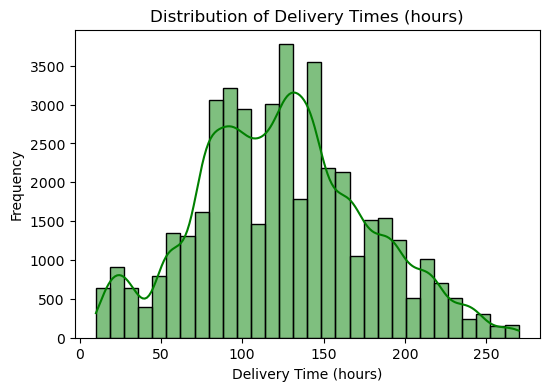

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df["Delivery_Time"], bins=30, kde=True, color="green")
plt.title("Distribution of Delivery Times (hours)")
plt.xlabel("Delivery Time (hours)")
plt.ylabel("Frequency")
plt.show()

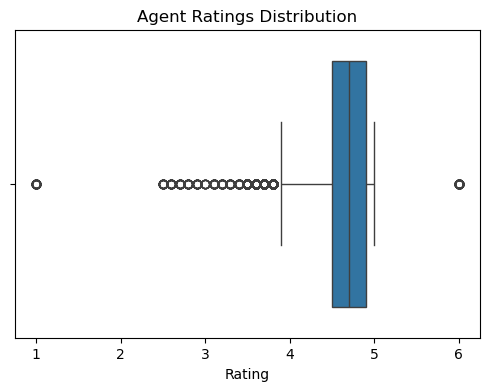

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Agent_Rating"])
plt.title("Agent Ratings Distribution")
plt.xlabel("Rating")
plt.show()

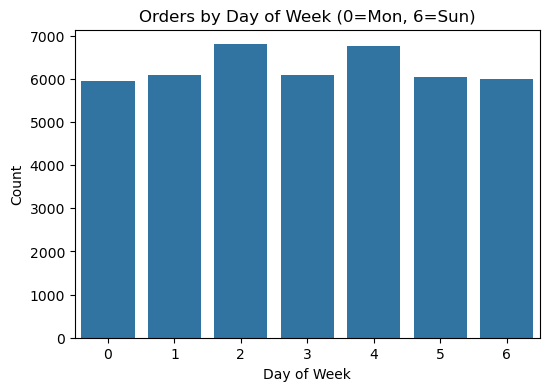

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["Order_Weekday"])
plt.title("Orders by Day of Week (0=Mon, 6=Sun)")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.show()

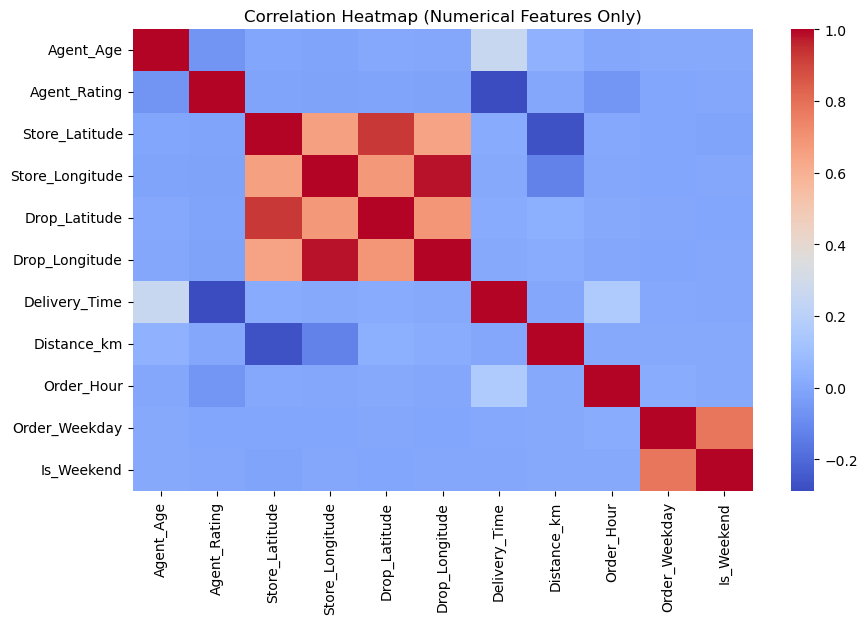

In [13]:
# Correlation heatmap (numerical features only)

numeric_df = df.select_dtypes(include=[np.number])  # only numeric columns
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap (Numerical Features Only)")
plt.show()

# EXPLORATORY DATA ANALYSIS

Steps:

-Load Cleaned Dataset (cleaned_amazon_delivery.csv)

-Basic Insights: shape, summary statistics, missing values check

-Delivery Time Analysis

-Distribution (histogram + KDE)

-Boxplot (outliers check)

-Impact of Factors on Delivery Time

-Traffic vs Delivery Time (boxplot / barplot)

-Weather vs Delivery Time

-Vehicle Type vs Delivery Time

-Area (Urban vs Metropolitan) vs Delivery Time

->Numerical Relationships

-Scatterplot: Distance vs Delivery Time

-Scatterplot: Agent Rating vs Delivery Time

-Correlation heatmap (numerical only)

->Agent Performance

-Delivery time distribution by Agent Age groups

-Agent Rating vs Delivery Time

-Key Insights (summary of findings to take into modeling)

In [14]:
# Day 2 - Exploratory Data Analysis (EDA)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# 1. Load cleaned dataset
df = pd.read_csv("cleaned_amazon_delivery.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (43739, 46)
        Order_ID  Agent_Age  Agent_Rating  Store_Latitude  Store_Longitude  \
0  ialx566343618         37           4.9       22.745049        75.892471   
1  akqg208421122         34           4.5       12.913041        77.683237   
2  njpu434582536         23           4.4       12.914264        77.678400   
3  rjto796129700         38           4.7       11.003669        76.976494   
4  zguw716275638         32           4.6       12.972793        80.249982   

   Drop_Latitude  Drop_Longitude  Order_Date Order_Time Pickup_Time  ...  \
0      22.765049       75.912471  2022-03-19   11:30:00    11:45:00  ...   
1      13.043041       77.813237  2022-03-25   19:45:00    19:50:00  ...   
2      12.924264       77.688400  2022-03-19   08:30:00    08:45:00  ...   
3      11.053669       77.026494  2022-04-05   18:00:00    18:10:00  ...   
4      13.012793       80.289982  2022-03-26   13:30:00    13:45:00  ...   

   Category_Pet Supplies  Category_Shoes  Category_Skin

In [16]:
# 2. Basic dataset insights
print(df.describe())
print("\nMissing values:\n", df.isnull().sum())

          Agent_Age  Agent_Rating  Store_Latitude  Store_Longitude  \
count  43739.000000   43739.00000    43739.000000     43739.000000   
mean      29.567137       4.63378       17.210960        70.661177   
std        5.815155       0.33451        7.764225        21.475005   
min       15.000000       1.00000      -30.902872       -88.366217   
25%       25.000000       4.50000       12.933298        73.170283   
50%       30.000000       4.70000       18.551440        75.898497   
75%       35.000000       4.90000       22.732225        78.045359   
max       50.000000       6.00000       30.914057        88.433452   

       Drop_Latitude  Drop_Longitude  Delivery_Time   Distance_km  \
count   43739.000000    43739.000000   43739.000000  43739.000000   
mean       17.459031       70.821842     124.905645     38.561752   
std         7.342950       21.153148      51.915451    534.564299   
min         0.010000        0.010000      10.000000      1.465067   
25%        12.985996    

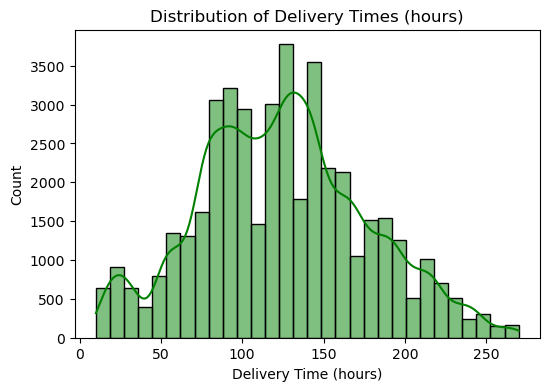

In [17]:
# 3. Delivery Time Distribution
plt.figure(figsize=(6,4))
sns.histplot(df["Delivery_Time"], bins=30, kde=True, color="green")
plt.title("Distribution of Delivery Times (hours)")
plt.xlabel("Delivery Time (hours)")
plt.ylabel("Count")
plt.show()

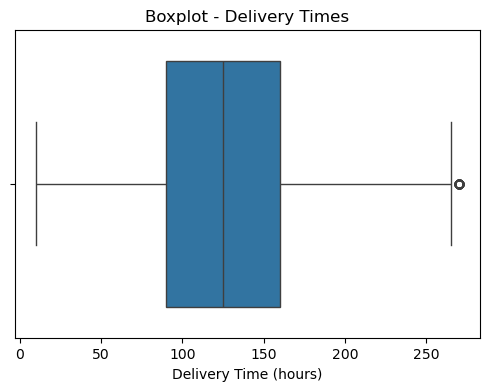

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["Delivery_Time"])
plt.title("Boxplot - Delivery Times")
plt.xlabel("Delivery Time (hours)")
plt.show()

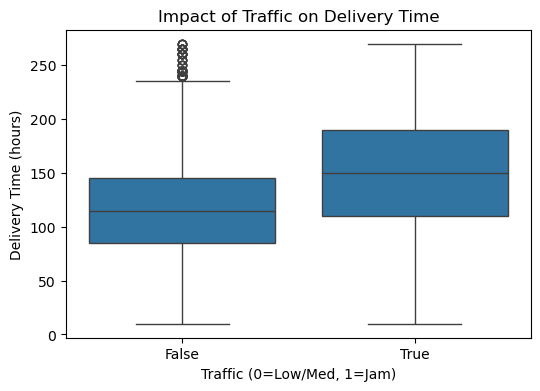

In [19]:
# 4. Impact of Factors
# 4. Impact of Categorical Factors (Dynamic Version)



plt.figure(figsize=(6,4))
sns.boxplot(x="Traffic_Jam ", y="Delivery_Time", data=df)
plt.title("Impact of Traffic on Delivery Time")
plt.xlabel("Traffic (0=Low/Med, 1=Jam)")
plt.ylabel("Delivery Time (hours)")
plt.show()

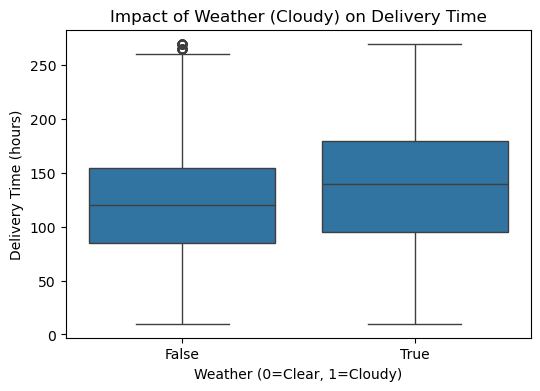

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Weather_Cloudy", y="Delivery_Time", data=df)
plt.title("Impact of Weather (Cloudy) on Delivery Time")
plt.xlabel("Weather (0=Clear, 1=Cloudy)")
plt.ylabel("Delivery Time (hours)")
plt.show()

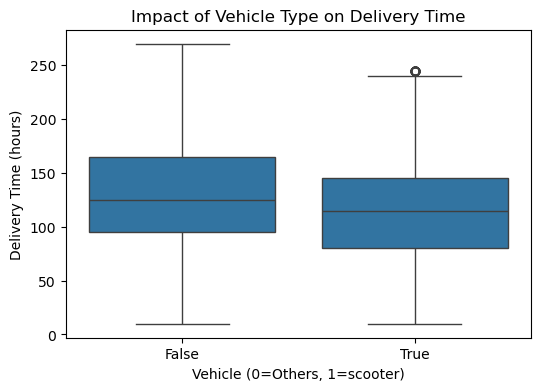

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Vehicle_scooter ", y="Delivery_Time", data=df)
plt.title("Impact of Vehicle Type on Delivery Time")
plt.xlabel("Vehicle (0=Others, 1=scooter)")
plt.ylabel("Delivery Time (hours)")
plt.show()

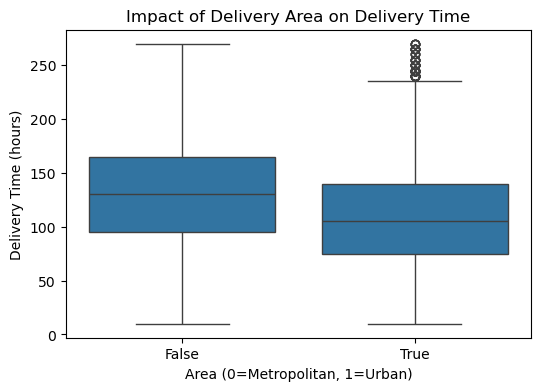

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Area_Urban ", y="Delivery_Time", data=df)
plt.title("Impact of Delivery Area on Delivery Time")
plt.xlabel("Area (0=Metropolitan, 1=Urban)")
plt.ylabel("Delivery Time (hours)")
plt.show()

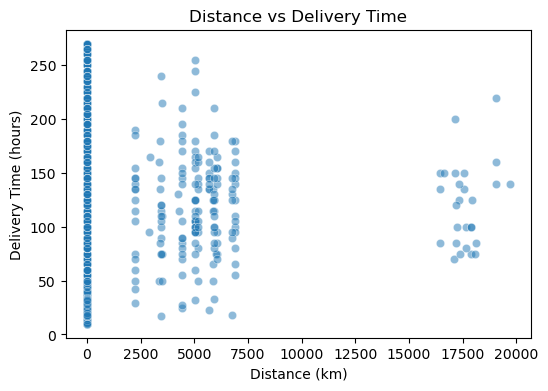

In [24]:
# 5. Numerical Relationships
plt.figure(figsize=(6,4))
sns.scatterplot(x="Distance_km", y="Delivery_Time", data=df, alpha=0.5)
plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (hours)")
plt.show()

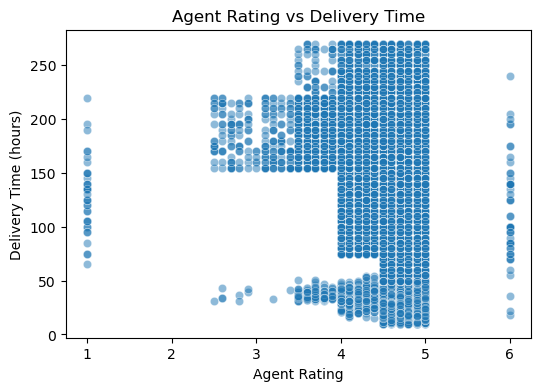

In [25]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="Agent_Rating", y="Delivery_Time", data=df, alpha=0.5)
plt.title("Agent Rating vs Delivery Time")
plt.xlabel("Agent Rating")
plt.ylabel("Delivery Time (hours)")
plt.show()

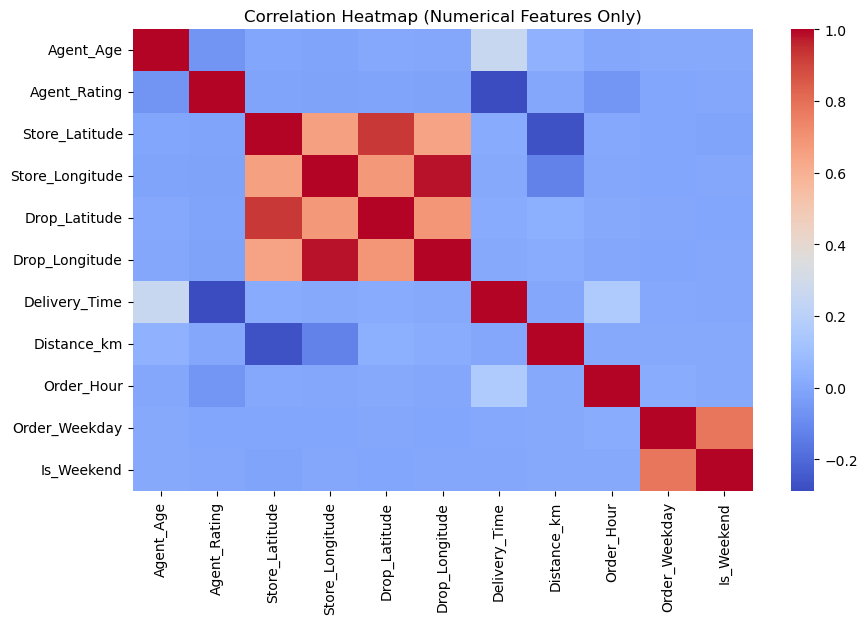

In [26]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=['float64','int64'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap (Numerical Features Only)")
plt.show()

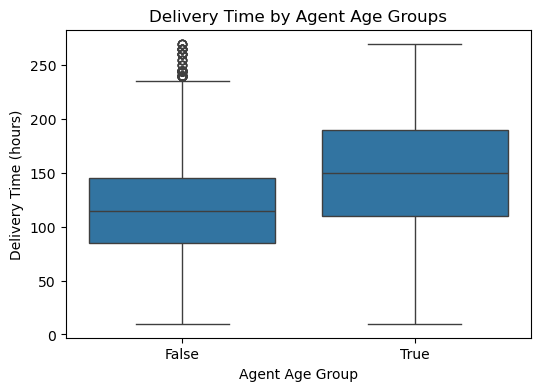

✅ EDA Completed. Key insights can be summarized after reviewing plots.


In [27]:
# 6. Agent Performance
df["Agent_Age_Group"] = pd.cut(df["Agent_Age"], bins=[18,25,35,45,60], labels=["18-25","26-35","36-45","46-60"])
plt.figure(figsize=(6,4))
sns.boxplot(x="Traffic_Jam ", y="Delivery_Time", data=df)


plt.title("Delivery Time by Agent Age Groups")
plt.xlabel("Agent Age Group")
plt.ylabel("Delivery Time (hours)")
plt.show()
# 7. Key Insights (to print later)
print("✅ EDA Completed. Key insights can be summarized after reviewing plots.")

In [28]:
print([col for col in df.columns if any(x in col for x in ["Traffic","Weather","Vehicle","Area"])])


['Weather_Cloudy', 'Weather_Fog', 'Weather_Sandstorms', 'Weather_Stormy', 'Weather_Sunny', 'Weather_Windy', 'Traffic_Jam ', 'Traffic_Low ', 'Traffic_Medium ', 'Traffic_NaN ', 'Vehicle_motorcycle ', 'Vehicle_scooter ', 'Vehicle_van', 'Area_Other', 'Area_Semi-Urban ', 'Area_Urban ']


**🧠Phase 3 – Model Training + MLflow Tracking**

We’ll:

-Split data into features/target

-Train multiple regression models

-Evaluate using RMSE, MAE, R²

-Track results with MLflow

-Save the best model for Streamlit

In [32]:
!pip install mlflow

Defaulting to user installation because normal site-packages is not writeable


In [34]:
# Find the column causing string-to-float conversion issue
for col in X_train.columns:
    if X_train[col].dtype == 'O':  # object type
        print(f"⚠️ Column '{col}' still contains non-numeric values!")
        print(X_train[col].unique()[:10])


NameError: name 'X_train' is not defined

In [35]:
# Day 3 - Model Training, Evaluation & MLflow Tracking


import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import mlflow
import mlflow.sklearn
import pickle

In [37]:
# Load cleaned dataset
df = pd.read_csv("cleaned_amazon_delivery.csv")

In [38]:
# Drop target and non-useful columns
X = df.drop(columns=["Delivery_Time", "Order_ID"], errors='ignore')
y = df["Delivery_Time"]

In [39]:
# Keep only numeric columns
X = X.select_dtypes(include=[np.number])

In [40]:
# Identify any remaining object/string columns
non_numeric_cols = df.drop(columns=["Delivery_Time", "Order_ID"], errors='ignore').select_dtypes(exclude=[np.number]).columns.tolist()
print("🔍 Non-numeric columns detected:", non_numeric_cols)

🔍 Non-numeric columns detected: ['Order_Date', 'Order_Time', 'Pickup_Time', 'Weather_Cloudy', 'Weather_Fog', 'Weather_Sandstorms', 'Weather_Stormy', 'Weather_Sunny', 'Weather_Windy', 'Traffic_Jam ', 'Traffic_Low ', 'Traffic_Medium ', 'Traffic_NaN ', 'Vehicle_motorcycle ', 'Vehicle_scooter ', 'Vehicle_van', 'Area_Other', 'Area_Semi-Urban ', 'Area_Urban ', 'Category_Books', 'Category_Clothing', 'Category_Cosmetics', 'Category_Electronics', 'Category_Grocery', 'Category_Home', 'Category_Jewelry', 'Category_Kitchen', 'Category_Outdoors', 'Category_Pet Supplies', 'Category_Shoes', 'Category_Skincare', 'Category_Snacks', 'Category_Sports', 'Category_Toys']


In [41]:
# Drop any of those from the dataset if they still exist in X
X = X.drop(columns=[col for col in non_numeric_cols if col in X.columns], errors='ignore')

In [42]:
# Coerce numeric conversion one last time
X = X.apply(pd.to_numeric, errors='coerce')

In [43]:
# Drop rows with invalid or missing data
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

print("✅ Final X shape:", X.shape)
print("✅ y shape:", y.shape)
print("✅ Data ready for model training!")

✅ Final X shape: (43648, 10)
✅ y shape: (43648,)
✅ Data ready for model training!


In [44]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
# Split features and target
X = df.drop(columns=["Delivery_Time", "Order_ID"])
y = df["Delivery_Time"]

In [46]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [47]:
# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

In [48]:
# Drop date/time columns from both training and test sets
drop_cols = ['Order_Date', 'Order_Time', 'Pickup_Time']
X_train = X_train.drop(columns=drop_cols, errors='ignore')
X_test = X_test.drop(columns=drop_cols, errors='ignore')

print("✅ Dropped columns:", drop_cols)
print("✅ Final training columns:", X_train.columns.tolist())

✅ Dropped columns: ['Order_Date', 'Order_Time', 'Pickup_Time']
✅ Final training columns: ['Agent_Age', 'Agent_Rating', 'Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude', 'Weather_Cloudy', 'Weather_Fog', 'Weather_Sandstorms', 'Weather_Stormy', 'Weather_Sunny', 'Weather_Windy', 'Traffic_Jam ', 'Traffic_Low ', 'Traffic_Medium ', 'Traffic_NaN ', 'Vehicle_motorcycle ', 'Vehicle_scooter ', 'Vehicle_van', 'Area_Other', 'Area_Semi-Urban ', 'Area_Urban ', 'Category_Books', 'Category_Clothing', 'Category_Cosmetics', 'Category_Electronics', 'Category_Grocery', 'Category_Home', 'Category_Jewelry', 'Category_Kitchen', 'Category_Outdoors', 'Category_Pet Supplies', 'Category_Shoes', 'Category_Skincare', 'Category_Snacks', 'Category_Sports', 'Category_Toys', 'Distance_km', 'Order_Hour', 'Order_Weekday', 'Is_Weekend']


In [49]:
# Start MLflow experiment
mlflow.set_experiment("Amazon_Delivery_Time_Prediction")

best_model = None
best_rmse = float("inf")

for name, model in models.items():
    with mlflow.start_run(run_name=name):
        # Train model
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # Evaluate
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)

        # Log metrics
        mlflow.log_metric("MAE", mae)
        mlflow.log_metric("RMSE", rmse)
        mlflow.log_metric("R2", r2)
        mlflow.sklearn.log_model(model, name.replace(" ", "_") + "_model")

        print(f"\n{name} Results:")
        print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}, R²: {r2:.3f}")

        # Save best model
        if rmse < best_rmse:
            best_rmse = rmse
            best_model = model

2026/04/15 23:18:27 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/15 23:18:27 INFO mlflow.store.db.utils: Updating database tables
2026/04/15 23:18:29 INFO mlflow.tracking.fluent: Experiment with name 'Amazon_Delivery_Time_Prediction' does not exist. Creating a new experiment.


ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [50]:
# Save best model locally for Streamlit
with open("best_delivery_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("\n✅ Best model saved as 'best_delivery_model.pkl'")


✅ Best model saved as 'best_delivery_model.pkl'


In [51]:
# Day 3 - Model Training, Evaluation & MLflow Tracking

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import mlflow
import mlflow.sklearn
import pickle

In [52]:
# ===============================================================
# 1️⃣ Load Cleaned Dataset
# ===============================================================
df = pd.read_csv("cleaned_amazon_delivery.csv")

In [53]:
# Define features and target
X = df.drop(columns=["Delivery_Time", "Order_ID"], errors='ignore')
y = df["Delivery_Time"]

In [54]:
# Drop any unwanted date/time columns (not needed for regression)
drop_cols = ['Order_Date', 'Order_Time', 'Pickup_Time']
X = X.drop(columns=drop_cols, errors='ignore')

In [55]:
# Keep only numeric columns
X = X.select_dtypes(include=[np.number])

print("✅ Feature columns:", X.columns.tolist())
print("✅ Initial X shape:", X.shape)

✅ Feature columns: ['Agent_Age', 'Agent_Rating', 'Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude', 'Distance_km', 'Order_Hour', 'Order_Weekday', 'Is_Weekend']
✅ Initial X shape: (43739, 10)


In [56]:
# ===============================================================
# 2️⃣ Handle Missing Values (Imputation or Drop)
# ===============================================================
# Optionally drop rows with too many NaNs first
X = X.dropna(how='all')
y = y.loc[X.index]

In [57]:
# Quick check
print("🔍 Total missing values before imputation:", X.isna().sum().sum())

🔍 Total missing values before imputation: 91


In [58]:
# ===============================================================
# 3️⃣ Train-Test Split
# ===============================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("✅ Data split complete:")
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

✅ Data split complete:
Train size: (34991, 10), Test size: (8748, 10)


In [59]:
# ===============================================================
# 4️⃣ Define Models with Imputation Pipelines
# ===============================================================
models = {
    "Linear Regression": Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('model', LinearRegression())
    ]),
    "Random Forest": Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('model', RandomForestRegressor(n_estimators=100, random_state=42))
    ]),
    "Gradient Boosting": Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('model', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
    ])
}

In [60]:
# ===============================================================
# 5️⃣ Start MLflow Experiment
# ===============================================================
mlflow.set_experiment("Amazon_Delivery_Time_Prediction")

best_model = None
best_rmse = float("inf")
results = []

for name, pipeline in models.items():
    with mlflow.start_run(run_name=name):
        # Train model
        pipeline.fit(X_train, y_train)
        preds = pipeline.predict(X_test)

        # Evaluate
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        r2 = r2_score(y_test, preds)

        # Cross-validation RMSE
        cv_rmse = np.mean(np.sqrt(-cross_val_score(
            pipeline, X_train, y_train,
            scoring='neg_mean_squared_error', cv=5
        )))

        # Log model params and metrics
        model_step = pipeline.named_steps['model']
        mlflow.log_params(model_step.get_params())
        mlflow.log_metrics({
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "CV_RMSE": cv_rmse
        })

        # Log model to MLflow
        mlflow.sklearn.log_model(pipeline, name.replace(" ", "_") + "_pipeline")

        # Print results
        print(f"\n📊 {name} Results:")
        print(f"MAE: {mae:.3f} | RMSE: {rmse:.3f} | R²: {r2:.3f} | CV_RMSE: {cv_rmse:.3f}")

        # Store for comparison
        results.append({
            "Model": name,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2,
            "CV_RMSE": cv_rmse
        })

        # Track best model
        if rmse < best_rmse:
            best_rmse = rmse
            best_model = pipeline

2026/04/15 23:21:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 23:21:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



📊 Linear Regression Results:
MAE: 36.399 | RMSE: 47.378 | R²: 0.157 | CV_RMSE: 47.632


2026/04/15 23:24:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 23:24:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



📊 Random Forest Results:
MAE: 32.585 | RMSE: 43.555 | R²: 0.288 | CV_RMSE: 43.309


2026/04/15 23:24:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/15 23:24:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



📊 Gradient Boosting Results:
MAE: 30.480 | RMSE: 41.059 | R²: 0.367 | CV_RMSE: 41.256


In [61]:
# ===============================================================
# 6️⃣ Save Best Model & Results
# ===============================================================
pd.DataFrame(results).to_csv("model_results.csv", index=False)
print("\n✅ All model results saved to 'model_results.csv'")

# Save best model for Streamlit
with open("best_delivery_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print(f"🏆 Best model saved as 'best_delivery_model.pkl' (RMSE: {best_rmse:.3f})")

print("\n🎯 Model training and MLflow tracking complete!")


✅ All model results saved to 'model_results.csv'
🏆 Best model saved as 'best_delivery_model.pkl' (RMSE: 41.059)

🎯 Model training and MLflow tracking complete!


# app.py — Amazon Delivery Time Prediction (Final Version)

import streamlit as st
import pandas as pd
import numpy as np
import pickle
from datetime import datetime

# =============================
# Load Trained Model
# =============================
with open("best_delivery_model.pkl", "rb") as f:
    model = pickle.load(f)

# =============================
# Streamlit Config
# =============================
st.set_page_config(page_title="Amazon Delivery Time Prediction", page_icon="📦", layout="centered")
st.title("📦 Amazon Delivery Time Prediction")
st.markdown("### 🚀 Predict how long a delivery will take based on real-world conditions.")
st.write("---")

# =============================
# Sidebar
# =============================
st.sidebar.header("ℹ️ Project Information")
st.sidebar.markdown("""
**Project:** Amazon Delivery Time Prediction  
**Goal:** Predict delivery duration (in hours)  
**Tech Stack:** Python, Scikit-learn, MLflow, Streamlit  
**Best Model:** Gradient Boosting Regressor ✅  

**Performance (Test Set):**  
- MAE ≈ 30.5  
- RMSE ≈ 41.1  
- R² ≈ 0.37  
""")

# =============================
# User Inputs
# =============================
st.header("🧠 Enter Delivery Details")

col1, col2 = st.columns(2)
with col1:
    distance = st.number_input("Distance (km)", min_value=0.1, max_value=100.0, value=5.0, step=0.1)
    agent_age = st.number_input("Agent Age", min_value=18, max_value=65, value=30)
    agent_rating = st.slider("Agent Rating (1–5)", 1.0, 5.0, 4.5, 0.1)
    order_date = st.date_input("Order Date", value=datetime.today())
with col2:
    order_time = st.time_input("Order Time", value=datetime.now().time())
    weather = st.selectbox("Weather Condition", ["Sunny", "Fog", "Cloudy", "Stormy", "Windy", "Sandstorms"])
    traffic = st.selectbox("Traffic Level", ["Low", "Medium", "Jam"])
    vehicle = st.selectbox("Vehicle Type", ["motorcycle", "scooter", "van"])
    area = st.selectbox("Delivery Area", ["Urban", "Semi-Urban", "Other"])
    category = st.selectbox("Product Category", [
        "Books", "Clothing", "Cosmetics", "Electronics", "Grocery", "Home", "Jewelry",
        "Kitchen", "Outdoors", "Pet Supplies", "Shoes", "Skincare", "Snacks", "Sports", "Toys"
    ])

st.write("---")

# =============================
# Feature Engineering (same as Day 1 pipeline)
# =============================

def create_feature_vector():
    data = {
        "Agent_Age": [agent_age],
        "Agent_Rating": [agent_rating],
        "Distance_km": [distance],
        "Order_Hour": [order_time.hour],
        "Order_Weekday": [order_date.weekday()],
        "Is_Weekend": [1 if order_date.weekday() >= 5 else 0],
    }

    # Base DF
    df = pd.DataFrame(data)

    # One-hot encoded categorical columns (aligning with training set)
    weather_cols = ['Weather_Cloudy', 'Weather_Fog', 'Weather_Sandstorms',
                    'Weather_Stormy', 'Weather_Sunny', 'Weather_Windy']
    traffic_cols = ['Traffic_Jam ', 'Traffic_Low ', 'Traffic_Medium ', 'Traffic_NaN ']
    vehicle_cols = ['Vehicle_motorcycle ', 'Vehicle_scooter ', 'Vehicle_van']
    area_cols = ['Area_Other', 'Area_Semi-Urban ', 'Area_Urban ']
    category_cols = [
        'Category_Books', 'Category_Clothing', 'Category_Cosmetics', 'Category_Electronics',
        'Category_Grocery', 'Category_Home', 'Category_Jewelry', 'Category_Kitchen',
        'Category_Outdoors', 'Category_Pet Supplies', 'Category_Shoes', 'Category_Skincare',
        'Category_Snacks', 'Category_Sports', 'Category_Toys'
    ]

    # Initialize all to 0
    for col in weather_cols + traffic_cols + vehicle_cols + area_cols + category_cols:
        df[col] = 0

    # Activate the selected ones
    df[f"Weather_{weather}"] = 1
    df[f"Traffic_{traffic} "] = 1
    df[f"Vehicle_{vehicle} "] = 1
    df[f"Area_{area} "] = 1
    df[f"Category_{category}"] = 1

    # Add placeholders for columns not used directly
    df["Drop_Latitude"] = 0.0
    df["Drop_Longitude"] = 0.0
    df["Store_Latitude"] = 0.0
    df["Store_Longitude"] = 0.0

    # Ensure correct column order
    expected_columns = model.feature_names_in_
    df = df.reindex(columns=expected_columns, fill_value=0)

    return df

# =============================
# Predict
# =============================
if st.button("🔮 Predict Delivery Time"):
    try:
        input_vector = create_feature_vector()
        prediction = model.predict(input_vector)[0]
        st.success(f"⏱️ Estimated Delivery Time: **{prediction:.2f} hours**")
    except Exception as e:
        st.error(f"⚠️ Prediction failed: {e}")

st.write("---")
st.caption("Built with ❤️ using Streamlit and Scikit-learn")
